In [1]:
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

# Read dataset:
- ds_a -- aerosol relateted dataset
- ds_c -- cloud property from mfrsrcldod1minC1
- ds_c_h -- resampled cloud height: top height bese height

#### if you need to run SGP, replace 'ENA' to 'SGP'

In [2]:
ds_a = xr.open_mfdataset('/data/ggong/ARM_monthly/SGP/rlprof_resample_2min.nc')
ds_c = xr.open_mfdataset('/data/ggong/ARM_monthly/SGP/mfrsrcldod1minC1.c1/mfrsrcldod_*_2min_resample.nc')
ds_c_h = xr.open_mfdataset('/data/ggong/ARM_monthly/SGP/cloud_height_2min_time_spot.nc')

ds_mete = xr.open_dataset('/data/ggong/ARM_monthly/SGP/RH_T_VWS_LTS_2min_extend_wss.nc')
ds_vv = xr.open_dataset('/data/ggong/ARM_monthly/SGP/VV_2min_750_850_extend.nc')
ds_vv600 = xr.open_dataset('/data/ggong/ARM_monthly/SGP/VV_2min_600_extend.nc')

ds_mete2 = xr.open_dataset('/data/ggong/ARM_monthly/SGP/RH34_T34_Tsurf_Windsurf_2min_extend.nc')
ds_lts2 = xr.open_dataset('/data/ggong/ARM_monthly/SGP/LTS_cloud_top_plus_2_extend.nc')

In [3]:
COD = ds_c.COD.values
Re  = ds_c.Re.values
lwp = ds_c.LWP.values*1000
CF  = ds_c.CF.values

## Dust Height / Thickness quality control

In [4]:
# 1) Extract base/top heights for single-layer clouds, and derive thickness / mean height
clb_km = ds_c_h["cloud_layer_base_height"] / 1000.0
clt_km = ds_c_h["cloud_layer_top_height"]  / 1000.0

valid_layer = (np.isfinite(clb_km) & np.isfinite(clt_km) & (clb_km >= 0) & (clt_km >= 0))
n_layers = valid_layer.sum(dim="layer")                    # Number of valid layers at each time
sel_idx  = valid_layer.astype(int).argmax(dim="layer")     # Position of the valid layer
sel_idx  = sel_idx.where(n_layers == 1)                    # Keep only single-layer clouds; set others to NaN

def take_by_idx(arr_1d, idx_scalar):
    if np.isnan(idx_scalar):
        return np.nan
    return arr_1d[int(idx_scalar)]

clb_1 = xr.apply_ufunc(
    take_by_idx, clb_km, sel_idx,
    input_core_dims=[["layer"], []],
    output_core_dims=[[]],
    vectorize=True, dask="parallelized",
    output_dtypes=[clb_km.dtype],
).rename("cloud_base_height")

clt_1 = xr.apply_ufunc(
    take_by_idx, clt_km, sel_idx,
    input_core_dims=[["layer"], []],
    output_core_dims=[[]],
    vectorize=True, dask="parallelized",
    output_dtypes=[clt_km.dtype],
).rename("cloud_top_height")

cloud_thickness = (clt_1 - clb_1).rename("cloud_geometric_thickness")
cloud_mean_h    = ((clt_1 + clb_1) * 0.5).rename("cloud_mean_height")

# 2) QC: base/top < 8 km
qc_mask = (clb_1 < 8.0) & (clt_1 < 8.0)

clb_qc = clb_1.where(qc_mask)
clt_qc = clt_1.where(qc_mask)
thk_qc = cloud_thickness.where(qc_mask)
mhn_qc = cloud_mean_h.where(qc_mask)

# 3) Calculate cloud-top temperature using nearest-neighbor indexing on ds_a height_high; fully vectorized
heights = ds_a["height_high"].values              # (H,)
cth     = clt_qc.values                           # (T,)

T = len(cth)
idx = np.full(T, np.nan, dtype=float)

mask_cth = np.isfinite(cth)
# For each valid time step, find the vertical-layer index closest to cloud-top height
idx[mask_cth] = np.abs(heights[np.newaxis, :] - cth[mask_cth, np.newaxis]).argmin(axis=1).astype(float)

# Extract temperature based on idx
temp2d   = ds_a["temperature"].values            # (T, H)
temp_cth = np.full(T, np.nan, dtype=np.float32)
valid_idx = ~np.isnan(idx)
temp_cth[valid_idx] = temp2d[np.arange(T)[valid_idx], idx[valid_idx].astype(int)]

temperature_at_cth = xr.DataArray(
    temp_cth, coords={"time": clt_qc.time}, dims="time", name="temperature_at_cth"
)

# 4) Assemble the dataset and apply the warm-cloud filter
ds_cloud_heights = xr.Dataset(
    {
        "cloud_base_height": clb_qc,
        "cloud_top_height": clt_qc,
        "cloud_geometric_thickness": thk_qc,
        "cloud_mean_height": mhn_qc,
        "temperature_at_cth": temperature_at_cth,
    }
)

T_K_WARM = 273.15
warm_mask = ds_cloud_heights["temperature_at_cth"] > T_K_WARM
ds_cloud_heights = ds_cloud_heights.where(warm_mask)

## Dust Height / Thickness quality control

In [5]:
# ===== parameters =====
valid_classes = [3, 9, 21, 37]
aerosol_class = 3
rain_class = 9
cloud_class = 21

dep_m  = 0.0049
dep_d  = 0.31
dep_nd = 0.15

hmin_km, hmax_km = 0.03, 8.0
ext_thresh = 1.25

# ====================== QC ======================
mask_qc = (
    (ds_a["detection_confidence_score_total"] >= 0.3)
    & (ds_a["qc_profile"] == 0)
    & ~(ds_a["feature_mask"] == 9).any(dim="height_high")
)

feature_mask = ds_a["feature_mask"].where(mask_qc)
pdr_meas     = ds_a["depolarization_ratio"].where(mask_qc)
ext          = ds_a["extinction_be"].where(mask_qc)
sca          = ds_a["scattering_ratio_e"].where(mask_qc)

# ====================== keep valid class ======================
mask_class = xr.zeros_like(feature_mask, dtype=bool)
for val in valid_classes:
    mask_class = mask_class | (feature_mask == val)

feature_mask = feature_mask.where(mask_class)
pdr_meas     = pdr_meas.where(mask_class)
ext          = ext.where(mask_class)
sca          = sca.where(mask_class)

# ====================== aerosol-only mask ======================
aerosol_mask = (feature_mask == aerosol_class)  & np.isfinite(ext) & (ext < ext_thresh)
pdr_meas_aerosol = pdr_meas.where(aerosol_mask)
sca_aerosol      = sca.where(aerosol_mask)
ext_aerosol      = ext.where(aerosol_mask)

# ====================== calculate PDR ======================
tepo = sca_aerosol + (sca_aerosol * dep_m) - dep_m
xnum = tepo * pdr_meas_aerosol - dep_m
xden = sca_aerosol - 1 + (sca_aerosol * dep_m) - pdr_meas_aerosol

eps = 1e-6
pdr = (xnum / xden).where(np.isfinite(xden) & (np.abs(xden) > eps))
pdr = pdr.where(np.isfinite(pdr) & (pdr >= 0) & (pdr <= 1.0))

# ====================== calculate dust fraction ======================
dust_frac = ((pdr - dep_nd) * (1 + dep_d)) / ((dep_d - dep_nd) * (1 + pdr))
dust_frac = dust_frac.where(pdr < dep_d, 1.0)
dust_frac = dust_frac.where(pdr > dep_nd, 0.0)
dust_frac = dust_frac.where(aerosol_mask)

# ====================== dust / non-dust extinction ======================
ext_dust    = dust_frac * ext_aerosol
ext_nondust = (1 - dust_frac) * ext_aerosol

# ====================== column AOD ======================
dz2d = xr.ones_like(ext_aerosol) * 0.03

AOD         = (ext_aerosol * dz2d).sum("height_high", min_count=1)
dust_AOD    = (ext_dust * dz2d).sum("height_high", min_count=1)
nondust_AOD = (ext_nondust * dz2d).sum("height_high", min_count=1)

In [6]:
# ===================================================================
# =============== Main dust layer identification + height metrics (dust_*) ===============
# ===================================================================

# Height coordinate (km)
z = ds_a["height_high"].values.astype(float)

# Adjacent-layer thickness (km), used as integration weights
dz_km = np.empty_like(z, dtype=float)
if len(z) < 2:
    raise ValueError("height_high dimension is too short to calculate dz")
dz_km[0]  = (z[1] - z[0])
dz_km[1:] = np.diff(z)

# Keep only positive dust extinction; preserve NaN as missing values
dust_ext = xr.where(ext_dust > 0, ext_dust, np.nan)
dust_mask_arr = xr.where(ext_dust > 0, True, False).fillna(False).values  # (time, height)
dust_ext_arr  = dust_ext.values                                           # (time, height)

T, H = dust_mask_arr.shape

base_km  = np.full(T, np.nan, dtype=float)  # dust_base_height
top_km   = np.full(T, np.nan, dtype=float)  # dust_top_height
mean_km  = np.full(T, np.nan, dtype=float)  # dust_mean_height = (base+top)/2
scale_km = np.full(T, np.nan, dtype=float)  # dust_scale_height (e-fold above base)
cent_km  = np.full(T, np.nan, dtype=float)  # dust_centroid_height (ext-weighted)
main_dod = np.full(T, np.nan, dtype=float)  # main dust optical depth

for t in range(T):
    m = dust_mask_arr[t]   # bool profile
    e = dust_ext_arr[t]    # dust extinction profile

    if not np.any(m):
        continue

    # ---- Find all continuous True dust-layer segments ----
    mm = m.astype(int)
    edges  = np.diff(np.concatenate(([0], mm, [0])))
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0] - 1  # inclusive

    if starts.size == 0:
        continue

    # ---- Select the "main dust layer": the segment with the largest layer dust AOD (∑ ext_dust * dz_km) ----
    best_idx = None
    best_int = -np.inf
    for s, eidx in zip(starts, ends):
        layer_ext = dust_ext_arr[t, s:eidx+1]
        layer_dz  = dz_km[s:eidx+1]
        integ = np.nansum(layer_ext * layer_dz)
        if np.isfinite(integ) and (integ > best_int):
            best_int = integ
            best_idx = (s, eidx)

    if best_idx is None:
        continue

    s, eidx = best_idx
    base_km[t] = z[s]
    top_km[t]  = z[eidx]
    mean_km[t] = 0.5 * (base_km[t] + top_km[t])

    layer_ext = dust_ext_arr[t, s:eidx+1]
    layer_z   = z[s:eidx+1]
    layer_dz  = dz_km[s:eidx+1]

    # ---- Main dust-layer DOD ----
    main_dod[t] = np.nansum(layer_ext * layer_dz)

    # ---- Centroid height: dust-extinction-weighted height within the main dust layer, ∫z*ext*dz / ∫ext*dz ----
    m_valid = np.isfinite(layer_ext) & (layer_ext > 0)
    if np.count_nonzero(m_valid) > 0:
        num = np.nansum(layer_ext[m_valid] * layer_z[m_valid] * layer_dz[m_valid])
        den = np.nansum(layer_ext[m_valid] *                 layer_dz[m_valid])
        if den > 0 and np.isfinite(num):
            cent_km[t] = num / den

    # ---- Scale height: height difference from layer base where ext0 decays to ext0/e, using linear interpolation in log space ----
    valid0 = np.where(np.isfinite(layer_ext) & (layer_ext > 0))[0]
    if valid0.size == 0:
        continue

    s0 = valid0[0]
    ext0 = layer_ext[s0]
    target = ext0 / np.e
    eps = 1e-12
    found = False

    for k in range(s0, len(layer_ext) - 1):
        y1, y2 = layer_ext[k], layer_ext[k+1]
        if not (np.isfinite(y1) and np.isfinite(y2) and y1 > eps and y2 > eps):
            continue
        if (y1 >= target and y2 <= target) or (y1 <= target and y2 >= target):
            z1, z2   = layer_z[k], layer_z[k+1]
            ly1, ly2 = np.log(y1), np.log(y2)
            ltar     = np.log(target)
            frac = (ltar - ly1) / (ly2 - ly1) if ly2 != ly1 else 0.0
            z_star = z1 + frac * (z2 - z1)
            scale_km[t] = z_star - layer_z[s0]
            found = True
            break

    if not found:
        y_top = layer_ext[-1]
        if np.isfinite(y_top) and y_top > eps and ext0 > eps and (ext0 / y_top) > 1.0:
            scale_km[t] = (layer_z[-1] - layer_z[s0]) / np.log(ext0 / y_top)
        else:
            scale_km[t] = np.nan

# ====================== Package results ======================
time_coord = ds_a["time"]
ds_dust_heights = xr.Dataset(
    data_vars=dict(
        dust_base_height = xr.DataArray(base_km, coords={"time": time_coord}, dims="time",
            attrs={"units":"km","long_name":"Dust layer base height (main dust layer)"}),
        dust_top_height  = xr.DataArray(top_km,  coords={"time": time_coord}, dims="time",
            attrs={"units":"km","long_name":"Dust layer top height (main dust layer)"}),
        dust_mean_height = xr.DataArray(mean_km, coords={"time": time_coord}, dims="time",
            attrs={"units":"km","long_name":"Mean dust height μ=(base+top)/2 (main dust layer)"}),
        dust_scale_height= xr.DataArray(scale_km,coords={"time": time_coord}, dims="time",
            attrs={"units":"km","long_name":"Dust scale height H (e-fold above base, main dust layer)"}),
        dust_centroid_height = xr.DataArray(cent_km, coords={"time": time_coord}, dims="time",
            attrs={"units":"km","long_name":"Dust extinction-weighted centroid height (main dust layer)"}),
        main_dod = xr.DataArray(main_dod, coords={"time": time_coord}, dims="time",
            attrs={"units":"1","long_name":"Dust optical depth of main dust layer"}),
    )
)

# Optional: add layer thickness ΔZ
ds_dust_heights["dust_layer_thickness"] = (
    ds_dust_heights["dust_top_height"] - ds_dust_heights["dust_base_height"]
)
ds_dust_heights["dust_layer_thickness"].attrs.update(
    {"units":"km","long_name":"Dust layer thickness ΔZ"}
)

## Aerosol-cloud collocation

In [7]:
dust_top_height  = ds_dust_heights["dust_top_height"].values
dust_base_height  = ds_dust_heights["dust_base_height"].values
dust_thickness = ds_dust_heights["dust_layer_thickness"].values
dust_mean_height = ds_dust_heights["dust_mean_height"].values

cloud_top_height  = ds_cloud_heights["cloud_top_height"].values
cloud_base_height  = ds_cloud_heights["cloud_base_height"].values
cloud_thickness = ds_cloud_heights["cloud_geometric_thickness"].values
cloud_mean_height = ds_cloud_heights["cloud_mean_height"].values

### Count the number of times each duration occurs

In [8]:
# Create a mask: True only when all values are non-NaN
valid_mask = (~np.isnan(dust_top_height) & ~np.isnan(dust_base_height) & ~np.isnan(cloud_top_height) & ~np.isnan(cloud_base_height))

# Initialize the output array (create a copy of the original array)
dust_top_height_new  = dust_top_height.copy()
dust_base_height_new = dust_base_height.copy()
dust_mean_height_new = dust_mean_height.copy()
dust_thickness_new = dust_thickness.copy()

cloud_top_height_new = cloud_top_height.copy()
cloud_base_height_new = cloud_base_height.copy()
cloud_mean_height_new = cloud_mean_height.copy()
cloud_thickness_new = cloud_thickness.copy()

# Set all invalid positions to NaN
dust_top_height_new[~valid_mask]  = np.nan
dust_base_height_new[~valid_mask] = np.nan
dust_mean_height_new[~valid_mask]  = np.nan
dust_thickness_new[~valid_mask] = np.nan

cloud_top_height_new[~valid_mask] = np.nan
cloud_base_height_new[~valid_mask] = np.nan
cloud_mean_height_new[~valid_mask] = np.nan
cloud_thickness_new[~valid_mask] = np.nan


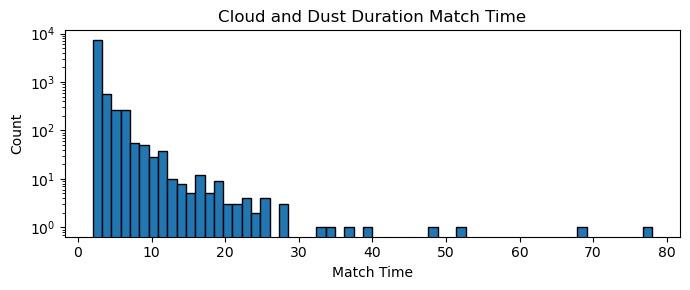

In [9]:
m = ~np.isnan(dust_top_height_new)
d = np.diff(m.astype(int))
L = np.where(d==-1)[0] - np.where(d==1)[0] + 1

plt.figure(figsize=(7,3),dpi=100)
plt.hist(L,bins=60,edgecolor="k")
plt.yscale("log")
plt.xlabel("Match Time"); plt.ylabel("Count"); plt.title("Cloud and Dust Duration Match Time")
plt.tight_layout(); plt.show()

# sample based classification

In [10]:
# ============================================================
# 1. Basic arrays
# ============================================================
LWP_all = np.asarray(ds_c.LWP.values, float) * 1000.0
COD_all = np.asarray(ds_c.COD.values, float)
Re_all  = np.asarray(ds_c.Re.values, float)
CF_all  = np.asarray(ds_c.CF.values, float)

DOD_all = np.asarray(dust_AOD.values if hasattr(dust_AOD, "values") else dust_AOD, float)
nondust_AOD_all = np.asarray(nondust_AOD.values if hasattr(nondust_AOD, "values") else nondust_AOD, float)
main_dod_all = np.asarray(ds_dust_heights.main_dod.values, float)

d_top  = np.asarray(dust_top_height_new, float)
d_base = np.asarray(dust_base_height_new, float)
c_top  = np.asarray(cloud_top_height_new, float)
c_base = np.asarray(cloud_base_height_new, float)

# ============================================================
# 2. QC mask before sample-level classification
# ============================================================
qc_mask = (
    valid_mask
    & np.isfinite(LWP_all) & (LWP_all >= 20) & (LWP_all <= 300)
    & np.isfinite(COD_all)
    & np.isfinite(Re_all)
    & np.isfinite(d_top)
    & np.isfinite(d_base)
    & np.isfinite(c_top)
    & np.isfinite(c_base)
    & (c_top <= 3.0)
)

In [11]:
# ============================================================
# 3. Sample-level dust-cloud vertical classification
# ============================================================
class_map = {
    "top": 0,
    "bottom": 1,
    "middle": 2,
    "decreasing": 3,
    "increasing": 4,
}

cat_names = list(class_map.keys())
labels = np.full(qc_mask.shape, np.nan)

m_top = qc_mask & (d_base - c_top > 0.1)

m_bottom = qc_mask & (c_base - d_top > 0.1)

m_middle = (
    qc_mask
    & ~m_top
    & ~m_bottom
    & (c_base - 0.1 < d_base)
    & (c_top + 0.1 > d_top)
)

m_decreasing = (
    qc_mask
    & ~m_top
    & ~m_bottom
    & ~m_middle
    & (c_base - 0.1 < d_top)
    & (d_top < c_top + 0.1)
    & (d_base < c_base - 0.1)
)

m_increasing = (
    qc_mask
    & ~m_top
    & ~m_bottom
    & ~m_middle
    & ~m_decreasing
    & (c_base - 0.1 < d_base)
    & (d_base < c_top + 0.1)
    & (d_top > c_top + 0.1)
)

labels[m_top]        = class_map["top"]
labels[m_bottom]     = class_map["bottom"]
labels[m_middle]     = class_map["middle"]
labels[m_decreasing] = class_map["decreasing"]
labels[m_increasing] = class_map["increasing"]


In [12]:
# ============================================================
# 4. Extract cloud / dust / microphysical variables by category
# ============================================================
cloud_mh_by_cat, dust_mh_by_cat = {}, {}
cloud_tn_by_cat, dust_tn_by_cat = {}, {}
cloud_th_by_cat, dust_th_by_cat = {}, {}
cloud_bh_by_cat, dust_bh_by_cat = {}, {}
COD_by_cat, re_by_cat, lwp_by_cat, cf_by_cat = {}, {}, {}, {}
DOD_by_cat, nondust_AOD_by_cat, main_dod_by_cat = {}, {}, {}

# Use actual observation time
time_all = pd.to_datetime(ds_c.time.values)

time_by_cat = {}

pairs1 = [
    (cloud_mh_by_cat, cloud_mean_height_new),
    (dust_mh_by_cat,  dust_mean_height_new),
    (cloud_tn_by_cat, cloud_thickness_new),
    (dust_tn_by_cat,  dust_thickness_new),
    (cloud_th_by_cat, cloud_top_height_new),
    (dust_th_by_cat,  dust_top_height_new),
    (cloud_bh_by_cat, cloud_base_height_new),
    (dust_bh_by_cat,  dust_base_height_new),
    (COD_by_cat, COD_all),
    (re_by_cat, Re_all),
    (lwp_by_cat, LWP_all),
    (cf_by_cat, CF_all),
    (DOD_by_cat, DOD_all),
    (nondust_AOD_by_cat, nondust_AOD_all),
    (main_dod_by_cat, main_dod_all),
]

for name in cat_names:
    m = labels == class_map[name]

    time_by_cat[name] = time_all[m]

    for d, arr in pairs1:
        d[name] = np.asarray(arr, float)[m]

# ============================================================
# 5. Extract meteorological variables by category
# ============================================================
RH = np.asarray(ds_mete.RH_750_850.values, float)
TEMP = np.asarray(ds_mete.TEMP_750_850.values, float)
VWS = np.asarray(ds_mete.VWS_725_925.values, float)
WSS = np.asarray(ds_mete.WSS_725_925.values, float)
LTS = np.asarray(ds_mete.LTS.values, float)
VV = np.asarray(ds_vv.w_750_850.values, float)

RH_34 = np.asarray(ds_mete2.RH_34.values, float)
TEMP_34 = np.asarray(ds_mete2.T_34.values, float)
Wind_surf = np.asarray(ds_mete2.Wind_surf.values, float)
TEMP_surf = np.asarray(ds_mete2.T_surf.values, float)
VV_4 = np.asarray(ds_vv600.w_600.values, float)
lts_2 = np.asarray(ds_lts2.LTS.values, float)

RH_by_cat, TEMP_by_cat, VWS_by_cat, WSS_by_cat, LTS_by_cat, VV_by_cat = {}, {}, {}, {}, {}, {}
RH_34_by_cat, TEMP_34_by_cat = {}, {}
Wind_surf_by_cat, TEMP_surf_by_cat = {}, {}
VV_4_by_cat, lts_2_by_cat = {}, {}

pairs2 = [
    (RH_by_cat, RH),
    (TEMP_by_cat, TEMP),
    (WSS_by_cat, WSS),
    (VWS_by_cat, VWS),
    (LTS_by_cat, LTS),
    (VV_by_cat, VV),
    (RH_34_by_cat, RH_34),
    (TEMP_34_by_cat, TEMP_34),
    (Wind_surf_by_cat, Wind_surf),
    (TEMP_surf_by_cat, TEMP_surf),
    (VV_4_by_cat, VV_4),
    (lts_2_by_cat, lts_2),
]

for name in cat_names:
    m = labels == class_map[name]
    for d, arr in pairs2:
        d[name] = np.asarray(arr, float)[m]

# save variables to a csv file

In [13]:
import pandas as pd
import numpy as np

cats = ["top", "middle", "bottom"]

vars_dict = {
    "cloud_mh": cloud_mh_by_cat, "dust_mh": dust_mh_by_cat,
    "cloud_tn": cloud_tn_by_cat, "dust_tn": dust_tn_by_cat,
    "cloud_th": cloud_th_by_cat, "dust_th": dust_th_by_cat,
    "cloud_bh": cloud_bh_by_cat, "dust_bh": dust_bh_by_cat,
    "COD": COD_by_cat, "lwp": lwp_by_cat, "Re": re_by_cat, "CF": cf_by_cat,
    "DOD": DOD_by_cat, "main_dod": main_dod_by_cat,
    "nondust_AOD": nondust_AOD_by_cat,
    "RH": RH_by_cat, "TEMP": TEMP_by_cat, "VWS": VWS_by_cat,
    "WSS": WSS_by_cat, "LTS": LTS_by_cat, "VV": VV_by_cat,
    "RH_34": RH_34_by_cat, "TEMP_34": TEMP_34_by_cat,
    "Wind_surf": Wind_surf_by_cat, "TEMP_surf": TEMP_surf_by_cat,
    "VV_4": VV_4_by_cat, "lts_2": lts_2_by_cat
}

# 2-min samples
dfs = []
for cat in cats:
    d = {k: v[cat] for k, v in vars_dict.items()}
    d.update(label=cat, time=pd.to_datetime(time_by_cat[cat]))
    dfs.append(pd.DataFrame(d))

sample_df = pd.concat(dfs, ignore_index=True).sort_values("time").reset_index(drop=True)

# New event if configuration changes or samples are not consecutive 2 min
new_event = (
    sample_df["label"].ne(sample_df["label"].shift()) |
    sample_df["time"].diff().ne(pd.Timedelta(minutes=2))
)
sample_df["event_id"] = new_event.cumsum()

# One row per event; numerical variables use median
event_df = (
    sample_df.groupby(["event_id", "label"])
    .agg(
        event_start=("time", "min"),
        event_end=("time", "max"),
        n_samples=("time", "size"),
        **{v: (v, "median") for v in vars_dict}
    )
    .reset_index()
)

event_df["event_mid"] = event_df["event_start"] + (
    event_df["event_end"] - event_df["event_start"]
) / 2

t = event_df["event_mid"].dt
event_df[["year", "month", "day", "hour", "minute"]] = np.column_stack(
    [t.year, t.month, t.day, t.hour, t.minute]
)

front = [
    "event_id", "label", "event_start", "event_end", "event_mid",
    "n_samples", "year", "month", "day", "hour", "minute"
]
event_df = event_df[front + [c for c in event_df.columns if c not in front]]

output = "/data/ggong/ARM_monthly/SGP/csv_file/df_abs_r_event.csv"
event_df.to_csv(output, index=False)

print(f"Saved: {output}")
display(event_df.head())

Saved: /data/ggong/ARM_monthly/SGP/csv_file/df_abs_r_event.csv


,event_id,label,event_start,event_end,event_mid,n_samples,year,month,day,hour,...,VWS,WSS,LTS,VV,RH_34,TEMP_34,Wind_surf,TEMP_surf,VV_4,lts_2
0,1,bottom,2016-03-06 13:58:00,2016-03-06 13:58:00,2016-03-06 13:58:00,1,2016,3,6,13,...,6.769981,-4.098305,16.367386,0.466678,36.902748,0.372484,8.653543,14.072901,3.07488,11.640808
1,2,bottom,2016-03-06 14:28:00,2016-03-06 14:28:00,2016-03-06 14:28:00,1,2016,3,6,14,...,7.431429,-2.957955,15.706635,0.892091,36.262665,0.433108,9.623796,14.944696,3.53074,11.899597
2,3,bottom,2016-03-06 15:44:00,2016-03-06 15:52:00,2016-03-06 15:48:00,5,2016,3,6,15,...,9.195290,0.082943,13.943893,1.210243,34.555779,0.594770,12.222443,17.269485,2.62664,6.489563
3,4,bottom,2016-03-06 16:00:00,2016-03-06 16:06:00,2016-03-06 16:03:00,4,2016,3,6,16,...,9.526013,0.652545,13.613266,1.099507,34.235737,0.625082,12.710936,17.705384,4.11183,6.598007
4,5,bottom,2016-03-06 17:36:00,2016-03-06 17:40:00,2016-03-06 17:38:00,3,2016,3,6,17,...,11.520554,4.099997,11.801300,0.544507,32.226875,0.816304,15.500005,20.190002,3.09008,5.542999
